# P&P Uncertainty Analysis

Reads from `rollouts.db` (written by `test_pi05.ipynb`) and produces:
- Uncertainty vs. success/failure correlation
- Per-task success rate vs. mean uncertainty
- Stepwise uncertainty over Euler steps and env timesteps
- P&P-enabled vs. disabled success rate comparison

In [50]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path

# ── Point this at your DB (local copy or Drive mount) ────────────────────────
DB_PATH = '/content/drive/MyDrive/smolvla_results/rollouts.db'

con = sqlite3.connect(DB_PATH)
con.row_factory = sqlite3.Row
print('Connected to', DB_PATH)

Connected to /content/drive/MyDrive/smolvla_results/rollouts.db


In [52]:
# ── Load tables into DataFrames ───────────────────────────────────────────────
rollouts = pd.read_sql('SELECT * FROM rollouts', con)
steps_df = pd.read_sql('SELECT * FROM pnp_euler_steps', con)

def parse_step_indices(s):
    try:
        return json.loads(s)
    except Exception:
        return s
rollouts['step_indices_parsed'] = rollouts['pnp_step_indices'].map(parse_step_indices)

# ── Step-config filter ────────────────────────────────────────────────────────
# Set to a JSON string (e.g. '[4, 5]') to restrict `pnp` to one config for
# targeted single-config inspection (cells 4, 5, 9, 10).
# Set to None (default) so phase2/phase3 aggregate across all configs — required
# for cross-config cells (6b, 17).
STEP_CONFIG_FILTER = None

# ── Split by phase ────────────────────────────────────────────────────────────
# pnp_all:  all P&P rows regardless of step config
# pnp:      optionally filtered — used by single-config inspection cells (4, 5, 9, 10)
# phase2/3: always all configs — used by cross-config and paired analysis cells
pnp_all  = rollouts[rollouts.pnp_enabled == 1].copy()
baseline = rollouts[rollouts.pnp_enabled == 0].copy()

pnp = pnp_all[pnp_all['pnp_step_indices'] == STEP_CONFIG_FILTER].copy() \
      if STEP_CONFIG_FILTER is not None else pnp_all.copy()

phase2 = pnp_all[pnp_all['pnp_mode'] == 'uncertainty'].copy()   # measure only, all configs
phase3 = pnp_all[pnp_all['pnp_mode'] == 'both'].copy()          # measure + refine, all configs

phase2_ids   = set(phase2['rollout_id'])
phase3_ids   = set(phase3['rollout_id'])
steps_phase2 = steps_df[steps_df['rollout_id'].isin(phase2_ids)].copy()
steps_phase3 = steps_df[steps_df['rollout_id'].isin(phase3_ids)].copy()

all_step_configs = sorted(pnp_all['pnp_step_indices'].dropna().unique().tolist())

print(f'rollouts total: {len(rollouts)} rows')
print(f'  baseline (pnp_enabled=0): {len(baseline)}')
print(f'  Step configs in DB: {all_step_configs}')
print(f'  Active filter: STEP_CONFIG_FILTER = {STEP_CONFIG_FILTER!r}')
print(f'  Phase 2  (pnp_mode=uncertainty, all configs): {len(phase2)}')
print(f'  Phase 3  (pnp_mode=both, all configs):        {len(phase3)}')
print(f'pnp_euler_steps: {len(steps_df)} rows  '
      f'(phase2={len(steps_phase2)}, phase3={len(steps_phase3)})')
print()
print('Suites:', rollouts.suite.unique().tolist())
print('Overall success rate (all):', rollouts.success.mean().round(3))
print('Phase 2 success rate:', phase2.success.mean().round(3) if len(phase2) else 'N/A')
print('Phase 3 success rate:', phase3.success.mean().round(3) if len(phase3) else 'N/A')


rollouts total: 682 rows
  baseline (pnp_enabled=0): 400
  Step configs in DB: ['[1, 2]', '[4, 5]', '[7, 8]']
  Active filter: STEP_CONFIG_FILTER = None
  Phase 2  (pnp_mode=uncertainty, all configs): 141
  Phase 3  (pnp_mode=both, all configs):        141
pnp_euler_steps: 2816 rows  (phase2=1420, phase3=1396)

Suites: ['libero_spatial', 'libero_object', 'libero_goal', 'libero_10']
Overall success rate (all): 0.783
Phase 2 success rate: 0.624
Phase 3 success rate: 0.66


In [53]:
# ── Per-task success rate + mean uncertainty (Phase 2) — per config ───────────
per_task = (
    phase2.groupby(['suite', 'task_idx', 'pnp_step_indices'])
    .agg(
        n_ep=('success', 'count'),
        sr=('success', 'mean'),
        u_mean_all=('u_mean_episode', 'mean'),
        u_mean_fail=('u_mean_episode', lambda x: x[phase2.loc[x.index, 'success'] == 0].mean()),
        u_mean_succ=('u_mean_episode', lambda x: x[phase2.loc[x.index, 'success'] == 1].mean()),
    )
    .reset_index()
)
print('Phase 2 — per-task SR and uncertainty (all configs):')
print(per_task.to_string(index=False))


Phase 2 — per-task SR and uncertainty (all configs):
         suite  task_idx pnp_step_indices  n_ep       sr  u_mean_all  u_mean_fail  u_mean_succ
     libero_10         0           [1, 2]     5 0.400000    0.018320     0.022565     0.011952
     libero_10         0           [4, 5]     5 0.600000    0.023142     0.025351     0.021669
     libero_10         0           [7, 8]     5 0.800000    0.022257     0.022550     0.022183
     libero_10         2           [1, 2]     1 1.000000    0.013111          NaN     0.013111
     libero_10         2           [4, 5]     1 1.000000    0.020350          NaN     0.020350
     libero_10         2           [7, 8]     1 1.000000    0.022562          NaN     0.022562
     libero_10         3           [1, 2]     2 0.500000    0.016381     0.018120     0.014641
     libero_10         3           [4, 5]     2 1.000000    0.022877          NaN     0.022877
     libero_10         3           [7, 8]     2 1.000000    0.022631          NaN     0.0226

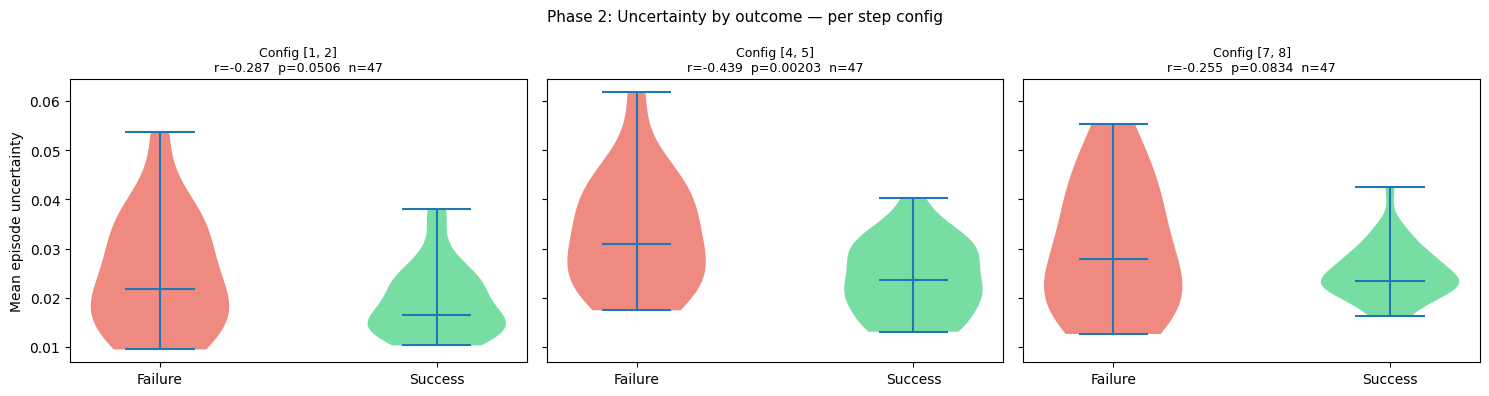

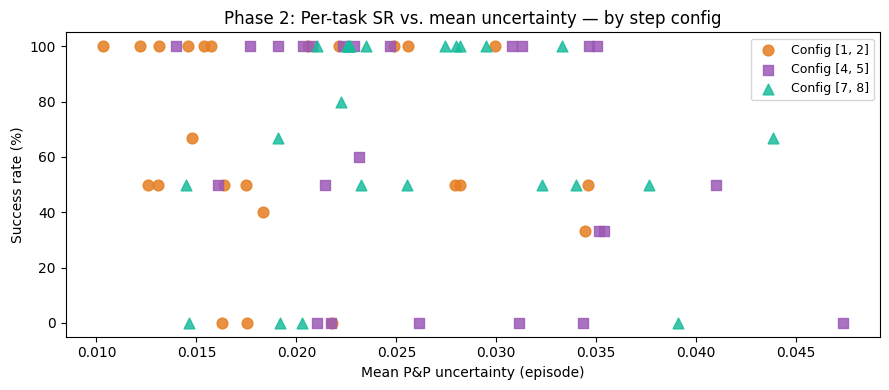

In [54]:
# ── Uncertainty vs. outcome — per step config ─────────────────────────────────
configs = sorted(phase2['pnp_step_indices'].dropna().unique())
cfg_colors = {'[1, 2]': '#e67e22', '[4, 5]': '#9b59b6', '[7, 8]': '#1abc9c'}
cfg_markers = {'[1, 2]': 'o', '[4, 5]': 's', '[7, 8]': '^'}

# ── Violin: success vs. failure uncertainty, one panel per config ──────────────
fig, axes = plt.subplots(1, len(configs), figsize=(5 * len(configs), 4), sharey=True)
if len(configs) == 1:
    axes = [axes]
for ax, cfg in zip(axes, configs):
    sub = phase2[phase2['pnp_step_indices'] == cfg].dropna(subset=['u_mean_episode'])
    succ_u = sub.loc[sub.success == 1, 'u_mean_episode']
    fail_u = sub.loc[sub.success == 0, 'u_mean_episode']
    data   = [g for g in [fail_u, succ_u] if len(g) > 1]
    lbls   = [l for g, l in zip([fail_u, succ_u], ['Failure', 'Success']) if len(g) > 1]
    if data:
        vp = ax.violinplot(data, positions=range(len(data)), showmedians=True)
        outcome_c = ['#e74c3c', '#2ecc71']
        for body, c in zip(vp['bodies'], [outcome_c[i] for i, g in enumerate([fail_u, succ_u]) if len(g) > 1]):
            body.set_facecolor(c); body.set_alpha(0.65)
        ax.set_xticks(range(len(data))); ax.set_xticklabels(lbls)
    r_val, p_val = (stats.pointbiserialr(sub['success'], sub['u_mean_episode'])
                    if sub['success'].nunique() == 2 else (float('nan'), float('nan')))
    ax.set_title(f'Config {cfg}\nr={r_val:.3f}  p={p_val:.3g}  n={len(sub)}', fontsize=9)
    ax.set_ylabel('Mean episode uncertainty' if ax is axes[0] else '')
fig.suptitle('Phase 2: Uncertainty by outcome — per step config', fontsize=11)
plt.tight_layout()
plt.savefig('pnp_uncertainty_vs_outcome.png', dpi=150)
plt.show()

# ── Scatter: per-task SR vs mean uncertainty, colored and shaped by config ─────
fig, ax = plt.subplots(figsize=(9, 4))
for cfg, grp in per_task.groupby('pnp_step_indices'):
    ax.scatter(grp['u_mean_all'], grp['sr'] * 100,
               color=cfg_colors.get(cfg, 'gray'),
               marker=cfg_markers.get(cfg, 'o'),
               s=60, alpha=0.85, label=f'Config {cfg}', zorder=3)
ax.set_xlabel('Mean P&P uncertainty (episode)')
ax.set_ylabel('Success rate (%)')
ax.set_title('Phase 2: Per-task SR vs. mean uncertainty — by step config')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pnp_uncertainty_vs_outcome_scatter.png', dpi=150)
plt.show()


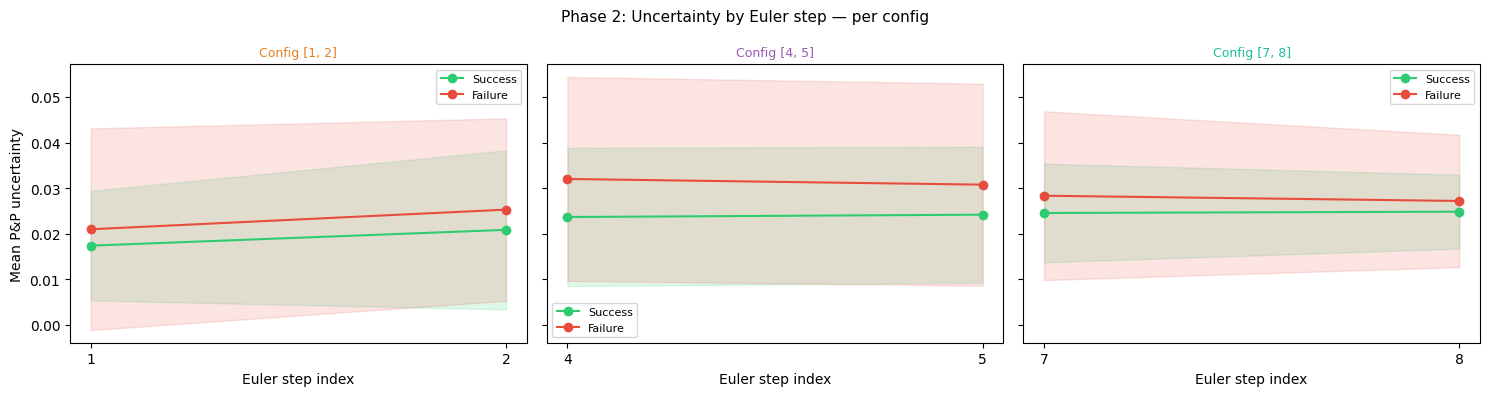

Per-step-position discriminability (Phase 2, all configs):
 euler_step         r        p   n config
          1 -0.098346 0.127089 242 [1, 2]
          2 -0.116703 0.069944 242 [1, 2]
          4 -0.207214 0.001215 241 [4, 5]
          5 -0.166813 0.009476 241 [4, 5]
          7 -0.123897 0.062380 227 [7, 8]
          8 -0.099297 0.135832 227 [7, 8]


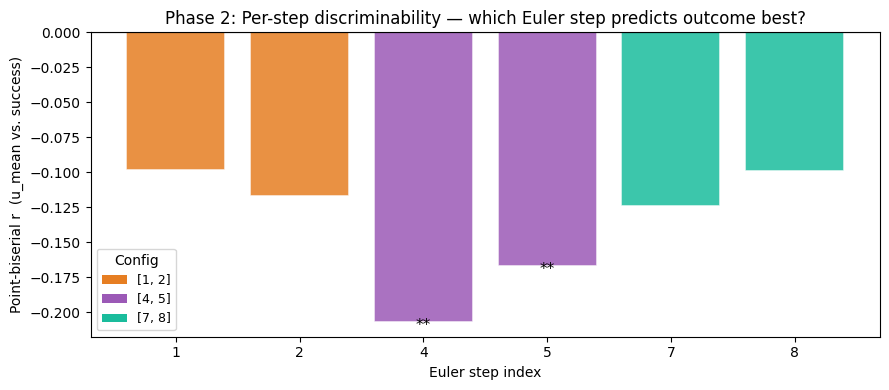

In [55]:
# ── Uncertainty by Euler step — Phase 2, one panel per config ─────────────────
# Steps_j2 built here; used by the cross-config overlay cell that follows.
steps_j2 = steps_phase2.merge(
    phase2[['rollout_id', 'success', 'suite', 'task_idx', 'pnp_step_indices']],
    on='rollout_id', how='left')

configs = sorted(steps_j2['pnp_step_indices'].dropna().unique())
config_colors = {'[1, 2]': '#e67e22', '[4, 5]': '#9b59b6', '[7, 8]': '#1abc9c'}

fig, axes = plt.subplots(1, len(configs), figsize=(5 * len(configs), 4), sharey=True)
if len(configs) == 1:
    axes = [axes]
for ax, cfg in zip(axes, configs):
    sub_cfg = steps_j2[steps_j2['pnp_step_indices'] == cfg]
    by_e = (sub_cfg.groupby(['euler_step', 'success'])
            .agg(u_mean=('u_mean', 'mean'), u_std=('u_mean', 'std'))
            .reset_index())
    for outcome, label, color in [(1, 'Success', '#2ecc71'), (0, 'Failure', '#e74c3c')]:
        sub = by_e[by_e.success == outcome].sort_values('euler_step')
        if sub.empty:
            continue
        ax.plot(sub['euler_step'], sub['u_mean'], marker='o', color=color, label=label)
        ax.fill_between(sub['euler_step'],
                        sub['u_mean'] - sub['u_std'],
                        sub['u_mean'] + sub['u_std'],
                        alpha=0.15, color=color)
    ax.set_xlabel('Euler step index')
    ax.set_ylabel('Mean P&P uncertainty' if ax is axes[0] else '')
    ax.set_title(f'Config {cfg}', fontsize=9,
                 color=config_colors.get(cfg, 'black'))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
fig.suptitle('Phase 2: Uncertainty by Euler step — per config', fontsize=11)
plt.tight_layout()
plt.savefig('pnp_uncertainty_by_euler_step.png', dpi=150)
plt.show()

# ── Per-step-position discriminability: point-biserial r ──────────────────────
from scipy.stats import pointbiserialr

step_to_config = (
    steps_j2.groupby('euler_step')['pnp_step_indices']
    .agg(lambda x: x.mode()[0]).to_dict()
)
step_corrs = []
for step_idx, grp in steps_j2.groupby('euler_step'):
    if grp['success'].nunique() < 2:
        continue
    r, p = pointbiserialr(grp['success'], grp['u_mean'])
    step_corrs.append({'euler_step': step_idx, 'r': r, 'p': p, 'n': len(grp),
                       'config': step_to_config.get(step_idx, '?')})

corr_df = pd.DataFrame(step_corrs).sort_values('euler_step')
print('Per-step-position discriminability (Phase 2, all configs):')
print(corr_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(corr_df['euler_step'].astype(str), corr_df['r'],
              color=[config_colors.get(c, '#95a5a6') for c in corr_df['config']],
              alpha=0.85, edgecolor='white', linewidth=1.2)
for bar, (_, row) in zip(bars, corr_df.iterrows()):
    sig = '**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else '')
    if sig:
        ax.text(bar.get_x() + bar.get_width() / 2,
                row['r'] + (0.003 if row['r'] >= 0 else -0.008),
                sig, ha='center', va='bottom', fontsize=11)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Euler step index')
ax.set_ylabel('Point-biserial r  (u_mean vs. success)')
ax.set_title('Phase 2: Per-step discriminability — which Euler step predicts outcome best?')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=v, label=k) for k, v in config_colors.items()],
          title='Config', fontsize=9)
plt.tight_layout()
plt.savefig('pnp_per_step_discriminability.png', dpi=150)
plt.show()


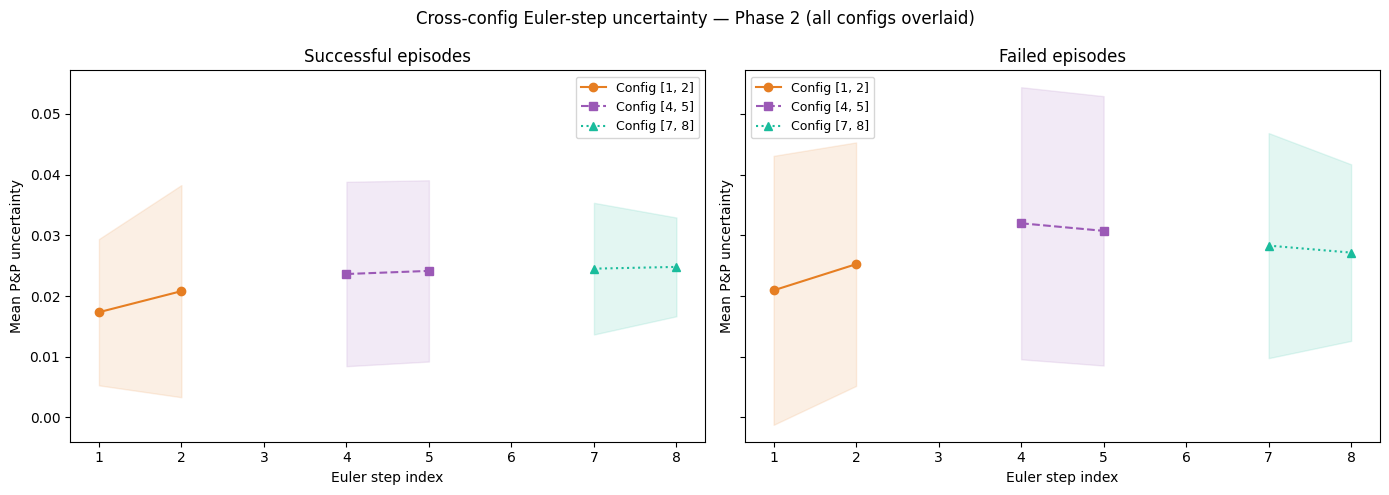

In [56]:
# ── Cross-config Euler-step overlay: all configs on the same axes ─────────────
# Shows whether early (1,2), mid (4,5), or late (7,8) denoising steps carry
# different success/failure separation, with each config's uncertainty profile
# plotted side-by-side for successes and failures.
config_styles = {
    '[1, 2]': ('#e67e22', 'o', '-'),
    '[4, 5]': ('#9b59b6', 's', '--'),
    '[7, 8]': ('#1abc9c', '^', ':'),
}

by_config_euler = (
    steps_j2.groupby(['pnp_step_indices', 'euler_step', 'success'])
    .agg(u_mean=('u_mean', 'mean'), u_std=('u_mean', 'std'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
panel_titles = {1: 'Successful episodes', 0: 'Failed episodes'}

for ax, outcome in zip(axes, [1, 0]):
    sub_all = by_config_euler[by_config_euler['success'] == outcome]
    for cfg, (color, marker, linestyle) in config_styles.items():
        sub = sub_all[sub_all['pnp_step_indices'] == cfg].sort_values('euler_step')
        if sub.empty:
            continue
        ax.plot(sub['euler_step'], sub['u_mean'],
                marker=marker, linestyle=linestyle, color=color, label=f'Config {cfg}')
        ax.fill_between(sub['euler_step'],
                        sub['u_mean'] - sub['u_std'],
                        sub['u_mean'] + sub['u_std'],
                        alpha=0.12, color=color)
    ax.set_xlabel('Euler step index')
    ax.set_ylabel('Mean P&P uncertainty')
    ax.set_title(panel_titles[outcome])
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)

fig.suptitle('Cross-config Euler-step uncertainty — Phase 2 (all configs overlaid)', fontsize=12)
plt.tight_layout()
plt.savefig('pnp_cross_config_euler_overlay.png', dpi=150)
plt.show()


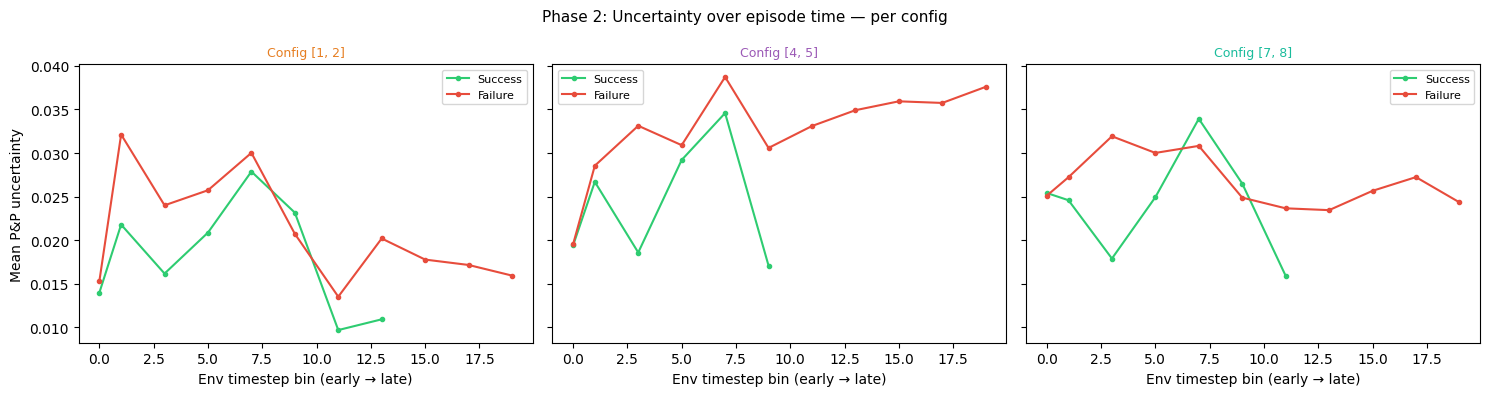

In [57]:
# ── Uncertainty over env timesteps — Phase 2, one panel per config ────────────
# Also builds by_bin2 (used by Phase 3 over-time cell below).
N_BINS = 20

# Join config into steps_j2 chunk data
by_chunk2_cfg = (
    steps_j2.groupby(['rollout_id', 'chunk_idx', 'success', 'pnp_step_indices'])
    .agg(u_mean_chunk=('u_mean', 'mean'))
    .reset_index()
)
by_chunk2_cfg['chunk_bin'] = pd.cut(by_chunk2_cfg['chunk_idx'], bins=N_BINS, labels=False)
by_bin2_cfg = (
    by_chunk2_cfg.groupby(['pnp_step_indices', 'chunk_bin', 'success'])
    .agg(u=('u_mean_chunk', 'mean'))
    .reset_index()
)

# Keep legacy by_bin2 (all configs combined) for the Phase 3 comparison cell
by_chunk2 = (
    steps_j2.groupby(['rollout_id', 'chunk_idx', 'success'])
    .agg(u_mean_chunk=('u_mean', 'mean'))
    .reset_index()
)
by_chunk2['chunk_bin'] = pd.cut(by_chunk2['chunk_idx'], bins=N_BINS, labels=False)
by_bin2 = (
    by_chunk2.groupby(['chunk_bin', 'success'])
    .agg(u=('u_mean_chunk', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, len(configs), figsize=(5 * len(configs), 4), sharey=True)
if len(configs) == 1:
    axes = [axes]
for ax, cfg in zip(axes, configs):
    sub_cfg = by_bin2_cfg[by_bin2_cfg['pnp_step_indices'] == cfg]
    for outcome, label, color in [(1, 'Success', '#2ecc71'), (0, 'Failure', '#e74c3c')]:
        sub = sub_cfg[sub_cfg.success == outcome].sort_values('chunk_bin')
        if sub.empty:
            continue
        ax.plot(sub['chunk_bin'], sub['u'], marker='.', color=color, label=label)
    ax.set_xlabel('Env timestep bin (early → late)')
    ax.set_ylabel('Mean P&P uncertainty' if ax is axes[0] else '')
    ax.set_title(f'Config {cfg}', fontsize=9, color=config_colors.get(cfg, 'black'))
    ax.legend(fontsize=8)
fig.suptitle('Phase 2: Uncertainty over episode time — per config', fontsize=11)
plt.tight_layout()
plt.savefig('pnp_uncertainty_over_time.png', dpi=150)
plt.show()


Paired episodes: 282
  Baseline SR:  0.0%
  P&P SR:       64.2%
  Failure→Success: 181
  Success→Failure: 0


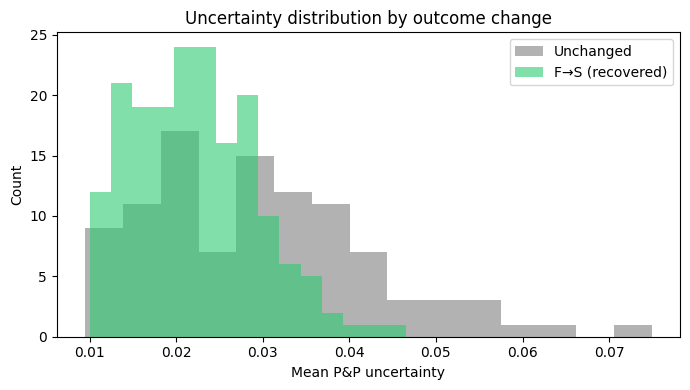

In [58]:
# ── Refinement comparison: P&P-enabled vs. disabled on same episodes ──────────
# Requires rollouts with pnp_enabled=0 AND pnp_enabled=1 for the same
# (suite, task_idx, episode_idx, init_state_hash). Run screening pass first.

base = rollouts[rollouts.pnp_enabled == 0][['suite','task_idx','episode_idx','init_state_hash','success']]
refined = rollouts[rollouts.pnp_enabled == 1][['suite','task_idx','episode_idx','init_state_hash','success','u_mean_episode']]

paired = base.merge(
    refined,
    on=['suite','task_idx','episode_idx','init_state_hash'],
    suffixes=('_base', '_pnp'))

if len(paired) == 0:
    print('No paired baseline/P&P runs yet — run screening pass (pnp_enabled=False) first.')
else:
    print(f'Paired episodes: {len(paired)}')
    print(f'  Baseline SR:  {paired.success_base.mean():.1%}')
    print(f'  P&P SR:       {paired.success_pnp.mean():.1%}')

    # Cases where outcome changed
    flip_to_success = paired[(paired.success_base == 0) & (paired.success_pnp == 1)]
    flip_to_failure = paired[(paired.success_base == 1) & (paired.success_pnp == 0)]
    print(f'  Failure→Success: {len(flip_to_success)}')
    print(f'  Success→Failure: {len(flip_to_failure)}')

    # Uncertainty of cases that changed
    fig, ax = plt.subplots(figsize=(7, 4))
    for group, label, color in [
        (paired[paired.success_base == paired.success_pnp], 'Unchanged', 'gray'),
        (flip_to_success, 'F→S (recovered)', '#2ecc71'),
        (flip_to_failure, 'S→F (degraded)', '#e74c3c'),
    ]:
        if len(group):
            ax.hist(group['u_mean_episode'], bins=15, alpha=0.6, label=label, color=color)
    ax.set_xlabel('Mean P&P uncertainty'); ax.set_ylabel('Count')
    ax.set_title('Uncertainty distribution by outcome change')
    ax.legend()
    plt.tight_layout()
    plt.savefig('pnp_refinement_comparison.png', dpi=150)
    plt.show()

In [59]:
# ── High-uncertainty failure cases (Phase 2): candidates for focused re-eval ──
failures2 = phase2[phase2.success == 0].dropna(subset=['u_mean_episode'])
top_failures2 = failures2.nlargest(20, 'u_mean_episode')[
    ['suite', 'task_idx', 'episode_idx', 'init_state_hash',
     'u_mean_episode', 'u_max_episode', 'n_steps', 'timestamp']]
print('Top-20 high-uncertainty failures (Phase 2):')
print(top_failures2.to_string(index=False))

Top-20 high-uncertainty failures (Phase 2):
         suite  task_idx  episode_idx init_state_hash  u_mean_episode  u_max_episode  n_steps           timestamp
libero_spatial         4            2    018f63f28fd6        0.061768       0.104494      220 2026-05-31T02:13:41
libero_spatial         8            4    68e59c35fbd7        0.055280       0.094541      220 2026-05-31T02:41:19
libero_spatial         4            2    018f63f28fd6        0.053679       0.116358      220 2026-05-30T12:56:17
libero_spatial         4            2    018f63f28fd6        0.049394       0.070077      220 2026-05-31T02:39:52
     libero_10         5            2    7a3c94a5136e        0.047344       0.134564      520 2026-05-31T01:50:31
libero_spatial         8            5    6954d4113e17        0.046729       0.084440      220 2026-05-31T02:17:32
libero_spatial         5            1    c0b272c317cd        0.044149       0.083092      220 2026-05-31T02:40:08
   libero_goal         3            4    bc9

Config [1, 2]: best t=0.01575  P=0.483  R=0.778  F1=0.596  n=47
Config [4, 5]: best t=0.02096  P=0.515  R=0.895  F1=0.654  n=47
Config [7, 8]: best t=0.03374  P=0.857  R=0.375  F1=0.522  n=47


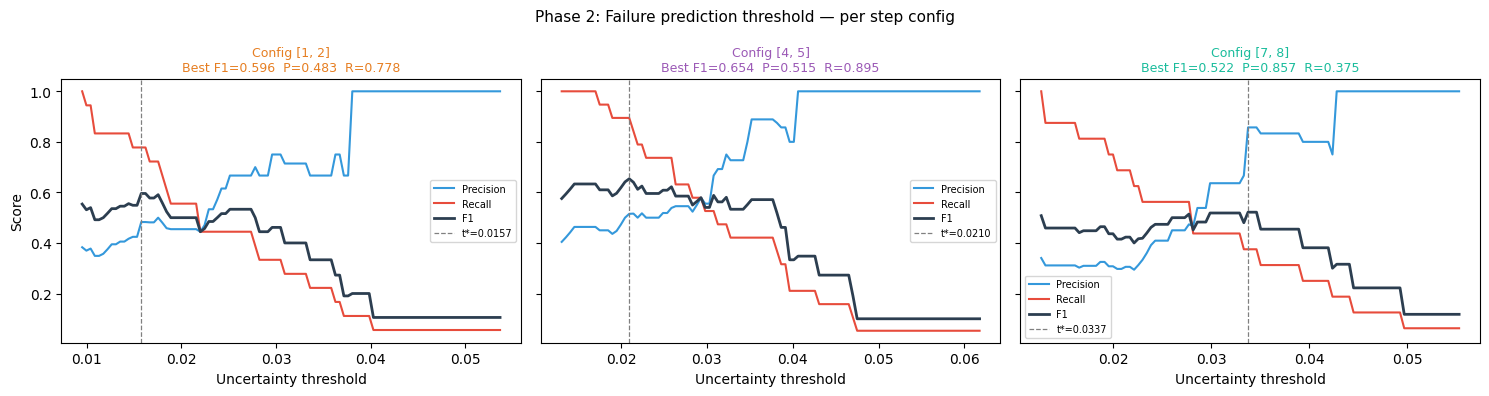

In [60]:
# ── Threshold analysis — per step config ──────────────────────────────────────
# Optimal threshold may differ per config because each probes different noise levels.
def threshold_curve(df):
    df = df.dropna(subset=['u_mean_episode'])
    thresholds = np.linspace(df.u_mean_episode.min(), df.u_mean_episode.max(), 100)
    precisions, recalls, f1s = [], [], []
    for t in thresholds:
        pred_fail = df.u_mean_episode >= t
        true_fail = df.success == 0
        tp = (pred_fail & true_fail).sum()
        fp = (pred_fail & ~true_fail).sum()
        fn = (~pred_fail & true_fail).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        precisions.append(prec); recalls.append(rec); f1s.append(f1)
    best = int(np.argmax(f1s))
    return thresholds, precisions, recalls, f1s, best

fig, axes = plt.subplots(1, len(configs), figsize=(5 * len(configs), 4), sharey=True)
if len(configs) == 1:
    axes = [axes]
for ax, cfg in zip(axes, configs):
    sub = phase2[phase2['pnp_step_indices'] == cfg]
    t, prec, rec, f1, best = threshold_curve(sub)
    ax.plot(t, prec, label='Precision', color='#3498db')
    ax.plot(t, rec,  label='Recall',    color='#e74c3c')
    ax.plot(t, f1,   label='F1',        color='#2c3e50', linewidth=2)
    ax.axvline(t[best], color='gray', linestyle='--', linewidth=0.9,
               label=f't*={t[best]:.4f}')
    ax.set_xlabel('Uncertainty threshold')
    ax.set_ylabel('Score' if ax is axes[0] else '')
    ax.set_title(f'Config {cfg}\nBest F1={f1[best]:.3f}  P={prec[best]:.3f}  R={rec[best]:.3f}',
                 fontsize=9, color=config_colors.get(cfg, 'black'))
    ax.legend(fontsize=7)
    print(f'Config {cfg}: best t={t[best]:.5f}  P={prec[best]:.3f}  R={rec[best]:.3f}  F1={f1[best]:.3f}  n={len(sub.dropna(subset=["u_mean_episode"]))}')
fig.suptitle('Phase 2: Failure prediction threshold — per step config', fontsize=11)
plt.tight_layout()
plt.savefig('pnp_threshold_analysis.png', dpi=150)
plt.show()


---
## Phase 3 Analysis (mode = 'both': measure + refine)

Phase 3 runs the same 47 failed Phase 1 episodes with P&P **refinement enabled** — the modified trajectory `x_acc` replaces the original `x_t` at each selected Euler step, actively steering the denoising toward lower-uncertainty actions.

In [61]:
# ── Phase 3 per-task success rate + uncertainty ───────────────────────────────
per_task3 = (
    phase3.groupby(['suite', 'task_idx'])
    .agg(
        n_ep=('success', 'count'),
        sr=('success', 'mean'),
        u_mean_all=('u_mean_episode', 'mean'),
        u_mean_fail=('u_mean_episode', lambda x: x[phase3.loc[x.index, 'success'] == 0].mean()),
        u_mean_succ=('u_mean_episode', lambda x: x[phase3.loc[x.index, 'success'] == 1].mean()),
    )
    .reset_index()
)
print(f'Phase 3 overall success rate: {phase3.success.mean():.1%}  '
      f'(vs Phase 2: {phase2.success.mean():.1%})')
print()
print('Phase 3 (refinement) — per-task SR and uncertainty:')
print(per_task3.to_string(index=False))

Phase 3 overall success rate: 66.0%  (vs Phase 2: 62.4%)

Phase 3 (refinement) — per-task SR and uncertainty:
         suite  task_idx  n_ep       sr  u_mean_all  u_mean_fail  u_mean_succ
     libero_10         0    15 0.733333    0.019972     0.022424     0.019080
     libero_10         2     3 1.000000    0.018199          NaN     0.018199
     libero_10         3     6 0.833333    0.021252     0.025906     0.020321
     libero_10         4     6 0.500000    0.014039     0.013176     0.014902
     libero_10         5     3 0.333333    0.029911     0.032282     0.025171
     libero_10         7     3 0.000000    0.027316     0.027316          NaN
     libero_10         8     3 0.333333    0.014885     0.017331     0.009994
     libero_10         9     6 0.833333    0.028791     0.031961     0.028157
   libero_goal         1     3 1.000000    0.017912          NaN     0.017912
   libero_goal         2     6 0.666667    0.030107     0.037140     0.026590
   libero_goal         3     6 0

Paired: 141  (3 configs × 47 episodes each)
  Phase 2 SR: 62.4%   Phase 3 SR: 66.0%


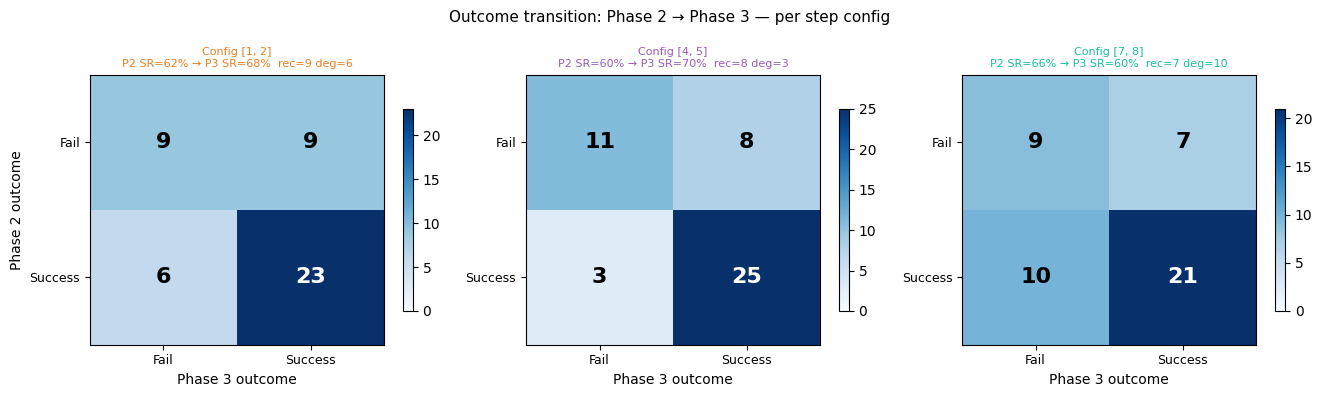

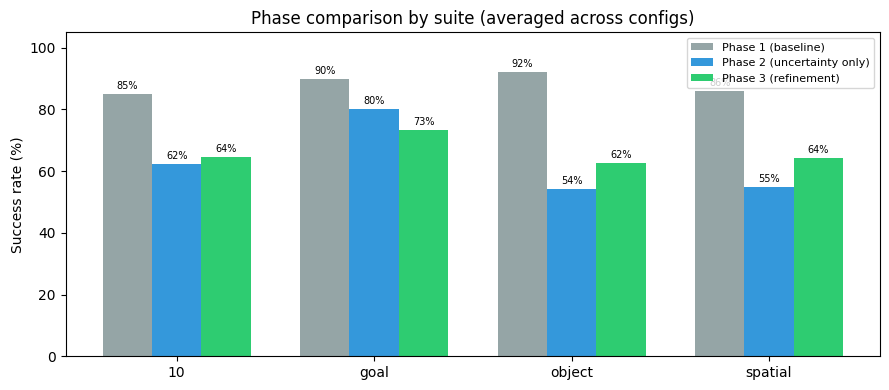

In [62]:
# ── Phase 2 vs Phase 3 head-to-head — transition matrix per config ────────────
paired = phase2.merge(
    phase3,
    on=['suite', 'task_idx', 'episode_idx', 'init_state_hash', 'pnp_step_indices'],
    suffixes=('_p2', '_p3'))

if len(paired) == 0:
    print('No paired Phase 2 / Phase 3 episodes found.')
else:
    print(f'Paired: {len(paired)}  ({paired.pnp_step_indices.nunique()} configs × '
          f'{len(paired) // paired.pnp_step_indices.nunique()} episodes each)')
    print(f'  Phase 2 SR: {paired.success_p2.mean():.1%}   Phase 3 SR: {paired.success_p3.mean():.1%}')

    # ── Per-config transition heatmaps ────────────────────────────────────────
    cfg_list = sorted(paired['pnp_step_indices'].unique())
    fig, axes = plt.subplots(1, len(cfg_list), figsize=(4.5 * len(cfg_list), 4))
    if len(cfg_list) == 1:
        axes = [axes]
    labels = {0: 'Fail', 1: 'Success'}
    for ax, cfg in zip(axes, cfg_list):
        sub = paired[paired['pnp_step_indices'] == cfg]
        trans = sub.groupby(['success_p2', 'success_p3']).size().unstack(fill_value=0)
        trans.index   = [labels.get(i, i) for i in trans.index]
        trans.columns = [labels.get(c, c) for c in trans.columns]
        # Ensure both axes have Fail and Success
        for lbl in ['Fail', 'Success']:
            if lbl not in trans.index:   trans.loc[lbl]    = 0
            if lbl not in trans.columns: trans[lbl]         = 0
        trans = trans.loc[['Fail', 'Success'], ['Fail', 'Success']]
        mat = trans.values
        im = ax.imshow(mat, cmap='Blues', aspect='auto', vmin=0)
        ax.set_xticks([0, 1]); ax.set_xticklabels(trans.columns, fontsize=9)
        ax.set_yticks([0, 1]); ax.set_yticklabels(trans.index, fontsize=9)
        ax.set_xlabel('Phase 3 outcome'); ax.set_ylabel('Phase 2 outcome' if ax is axes[0] else '')
        rec  = sub[(sub.success_p2==0) & (sub.success_p3==1)]
        deg  = sub[(sub.success_p2==1) & (sub.success_p3==0)]
        p2sr = sub.success_p2.mean(); p3sr = sub.success_p3.mean()
        ax.set_title(f'Config {cfg}\nP2 SR={p2sr:.0%} → P3 SR={p3sr:.0%}  '
                     f'rec={len(rec)} deg={len(deg)}', fontsize=8,
                     color=config_colors.get(cfg, 'black'))
        for i in range(2):
            for j in range(2):
                ax.text(j, i, mat[i, j], ha='center', va='center',
                        fontsize=16, fontweight='bold',
                        color='white' if mat[i, j] > mat.max() * 0.55 else 'black')
        plt.colorbar(im, ax=ax, shrink=0.75)
    fig.suptitle('Outcome transition: Phase 2 → Phase 3 — per step config', fontsize=11)
    plt.tight_layout()
    plt.savefig('pnp_phase_transition_by_config.png', dpi=150)
    plt.show()

    # ── Suite-level SR comparison (phases, averaged across configs) ───────────
    suites = sorted(phase2.suite.unique())
    x = np.arange(len(suites))
    w = 0.25
    sr2_suite  = phase2.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    sr3_suite  = phase3.groupby('suite')['success'].mean().reindex(suites).fillna(0)
    base_sr    = baseline.groupby('suite')['success'].mean().reindex(suites).fillna(0)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(x - w, base_sr * 100,  width=w, label='Phase 1 (baseline)',         color='#95a5a6')
    ax.bar(x,     sr2_suite * 100, width=w, label='Phase 2 (uncertainty only)', color='#3498db')
    ax.bar(x + w, sr3_suite * 100, width=w, label='Phase 3 (refinement)',       color='#2ecc71')
    ax.set_xticks(x); ax.set_xticklabels([s.replace('libero_', '') for s in suites])
    ax.set_ylabel('Success rate (%)'); ax.set_ylim(0, 105)
    ax.set_title('Phase comparison by suite (averaged across configs)')
    ax.legend(fontsize=8)
    for bars_patch, vals in [(ax.patches[:len(suites)], base_sr),
                              (ax.patches[len(suites):2*len(suites)], sr2_suite),
                              (ax.patches[2*len(suites):], sr3_suite)]:
        for bar, v in zip(bars_patch, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{v*100:.0f}%', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig('pnp_phase_comparison_by_suite.png', dpi=150)
    plt.show()


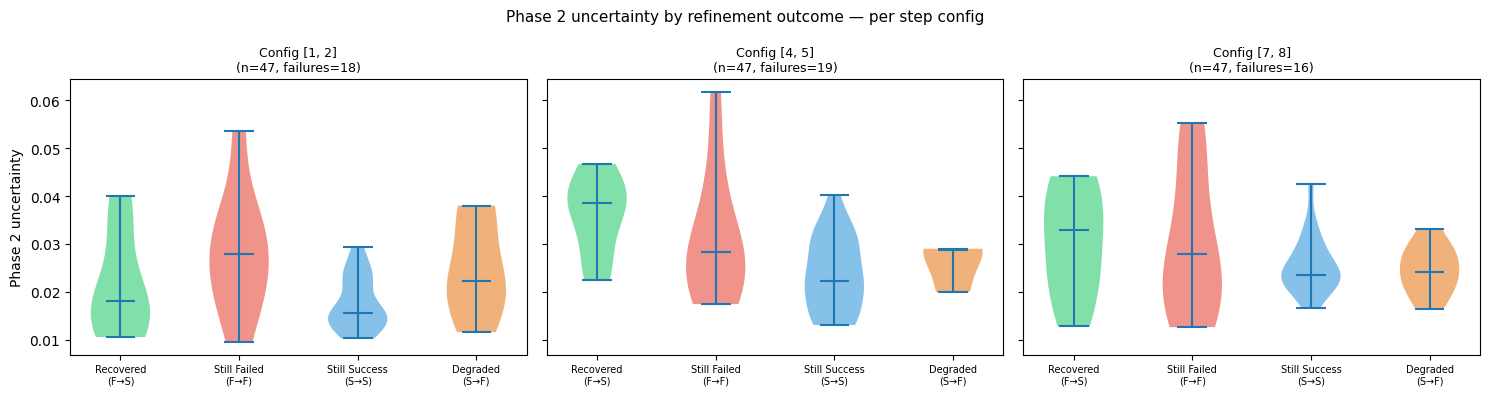

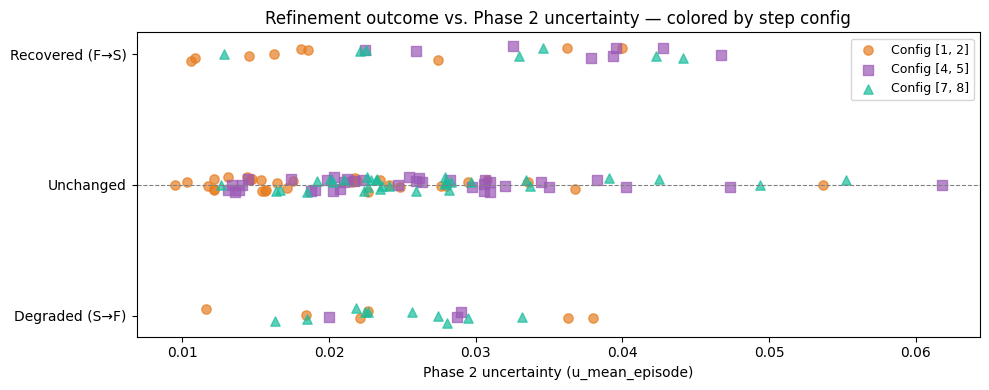

Recovery rate per step config (among Phase 1 failures only):
  Config [1, 2]: 18 failures → 50.0% recovered in Phase 3
  Config [4, 5]: 19 failures → 42.1% recovered in Phase 3
  Config [7, 8]: 16 failures → 43.8% recovered in Phase 3


In [63]:
# ── Uncertainty as predictor of refinement benefit — broken out by step config ─
# Key question: does Phase 2 uncertainty predict which episodes recover in Phase 3,
# and does that relationship differ across step-index configs?
if len(paired) > 0:
    def outcome_label(row):
        if row.success_p2 == 0 and row.success_p3 == 1:
            return 'Recovered\n(F→S)'
        elif row.success_p2 == 0 and row.success_p3 == 0:
            return 'Still Failed\n(F→F)'
        elif row.success_p2 == 1 and row.success_p3 == 1:
            return 'Still Success\n(S→S)'
        else:
            return 'Degraded\n(S→F)'

    paired['outcome_change'] = paired.apply(outcome_label, axis=1)
    paired['refined'] = paired.success_p3 - paired.success_p2

    order  = ['Recovered\n(F→S)', 'Still Failed\n(F→F)', 'Still Success\n(S→S)', 'Degraded\n(S→F)']
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22']
    configs = sorted(paired['pnp_step_indices'].unique())
    cfg_colors = {'[1, 2]': '#e67e22', '[4, 5]': '#9b59b6', '[7, 8]': '#1abc9c'}

    # ── Row 1: Violin per config — uncertainty distribution by outcome category ──
    fig, axes = plt.subplots(1, len(configs), figsize=(5 * len(configs), 4), sharey=True)
    if len(configs) == 1:
        axes = [axes]
    for ax, cfg in zip(axes, configs):
        sub = paired[paired['pnp_step_indices'] == cfg]
        groups = [sub.loc[sub.outcome_change == lbl, 'u_mean_episode_p2'].dropna()
                  for lbl in order]
        non_empty = [(g, lbl, c) for g, lbl, c in zip(groups, order, colors) if len(g) > 1]
        single    = [(g, lbl, c) for g, lbl, c in zip(groups, order, colors)
                     if len(g) == 1]
        if non_empty:
            vp = ax.violinplot([g for g, _, _ in non_empty],
                               positions=range(len(non_empty)), showmedians=True)
            for body, (_, _, c) in zip(vp['bodies'], non_empty):
                body.set_facecolor(c); body.set_alpha(0.6)
            ax.set_xticks(range(len(non_empty)))
            ax.set_xticklabels([lbl for _, lbl, _ in non_empty], fontsize=7)
        for i, (g, lbl, c) in enumerate(single):
            ax.scatter([len(non_empty) + i], g, color=c, zorder=3, s=50)
        n_rec  = (sub.success_p2 == 0).sum()
        ax.set_title(f'Config {cfg}\n(n={len(sub)}, failures={n_rec})', fontsize=9)
        ax.set_ylabel('Phase 2 uncertainty' if ax == axes[0] else '')
    fig.suptitle('Phase 2 uncertainty by refinement outcome — per step config', fontsize=11)
    plt.tight_layout()
    plt.savefig('pnp_phase3_uncertainty_vs_recovery.png', dpi=150)
    plt.show()

    # ── Row 2: Scatter — Phase 2 uncertainty vs refinement outcome, colored by config ─
    fig, ax = plt.subplots(figsize=(10, 4))
    markers = {'[1, 2]': 'o', '[4, 5]': 's', '[7, 8]': '^'}
    for cfg, grp in paired.groupby('pnp_step_indices'):
        jitter = np.random.default_rng(42).uniform(-0.06, 0.06, len(grp))
        ax.scatter(grp['u_mean_episode_p2'], grp['refined'] + jitter,
                   color=cfg_colors.get(cfg, 'gray'),
                   marker=markers.get(cfg, 'o'),
                   alpha=0.7, s=45, label=f'Config {cfg}')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(['Degraded (S→F)', 'Unchanged', 'Recovered (F→S)'])
    ax.set_xlabel('Phase 2 uncertainty (u_mean_episode)')
    ax.set_title('Refinement outcome vs. Phase 2 uncertainty — colored by step config')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('pnp_phase3_uncertainty_vs_recovery_scatter.png', dpi=150)
    plt.show()

    # ── Summary: recovery rate per config ─────────────────────────────────────
    print('Recovery rate per step config (among Phase 1 failures only):')
    for cfg, grp in paired.groupby('pnp_step_indices'):
        failures = grp[grp.success_p2 == 0]
        rec_rate = failures.success_p3.mean() if len(failures) else float('nan')
        print(f'  Config {cfg}: {len(failures)} failures → {rec_rate:.1%} recovered in Phase 3')
else:
    print('No paired data — skipping uncertainty-vs-recovery plot.')


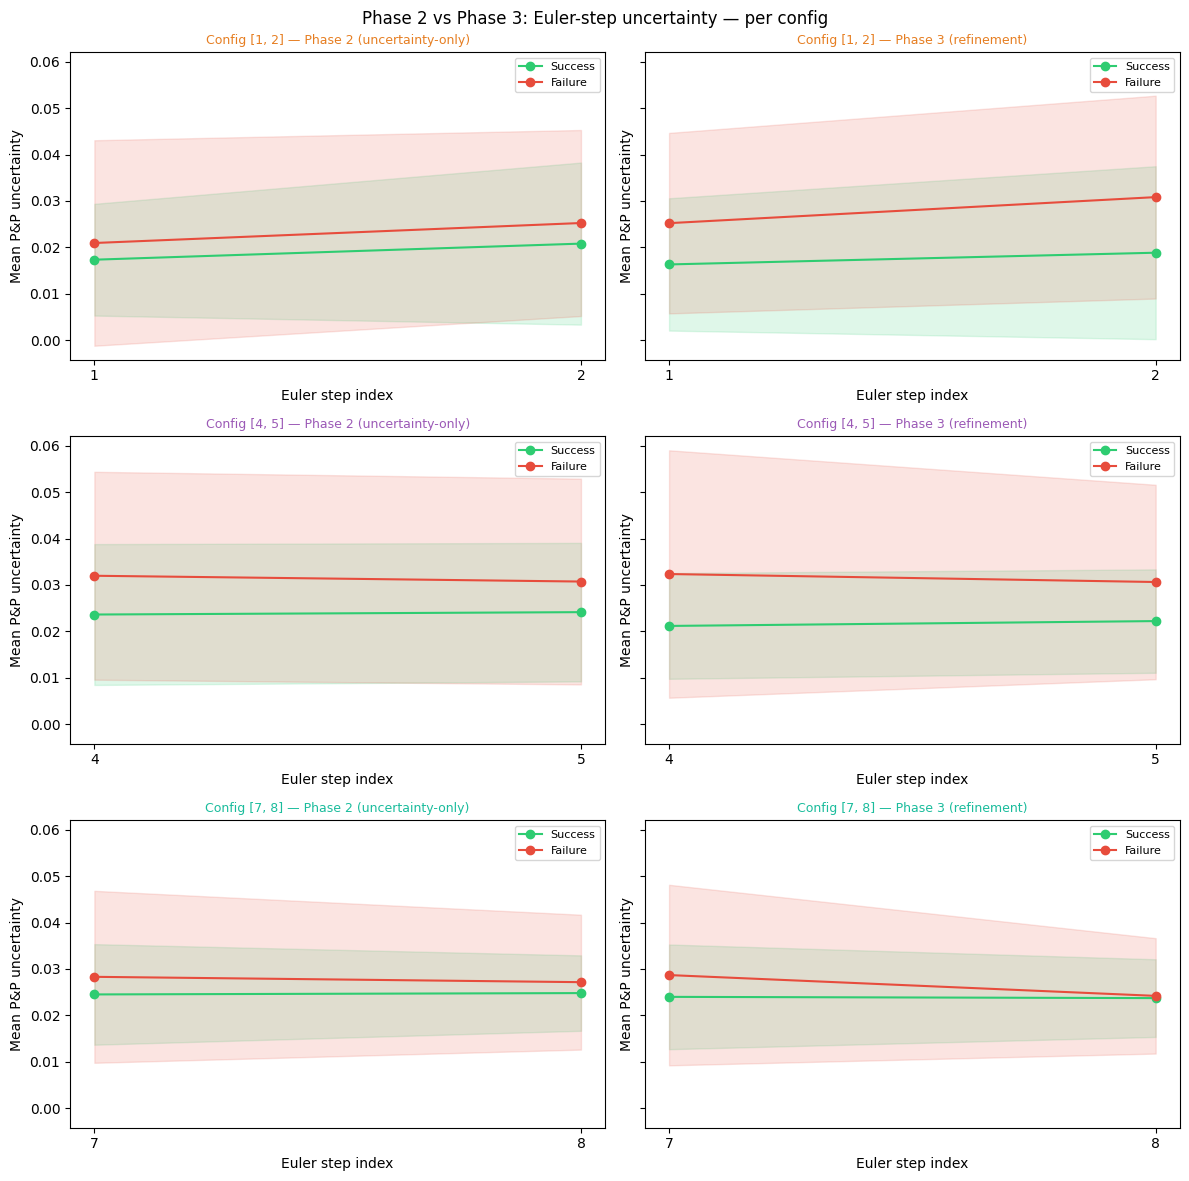

In [64]:
# ── Phase 2 vs Phase 3 Euler-step uncertainty — per config ────────────────────
steps_j3 = steps_phase3.merge(
    phase3[['rollout_id', 'success', 'suite', 'task_idx', 'pnp_step_indices']],
    on='rollout_id', how='left')

fig, axes = plt.subplots(len(configs), 2,
                          figsize=(12, 4 * len(configs)),
                          sharey=True, sharex=False)
# Ensure 2D even for single config
if len(configs) == 1:
    axes = [axes]

for row_axes, cfg in zip(axes, configs):
    sub2 = steps_j2[steps_j2['pnp_step_indices'] == cfg]
    sub3 = steps_j3[steps_j3['pnp_step_indices'] == cfg]
    for ax, steps_sub, phase_label in [
        (row_axes[0], sub2, 'Phase 2 (uncertainty-only)'),
        (row_axes[1], sub3, 'Phase 3 (refinement)'),
    ]:
        by_e = (steps_sub.groupby(['euler_step', 'success'])
                .agg(u_mean=('u_mean', 'mean'), u_std=('u_mean', 'std'))
                .reset_index())
        for outcome, label, color in [(1, 'Success', '#2ecc71'), (0, 'Failure', '#e74c3c')]:
            sub = by_e[by_e.success == outcome].sort_values('euler_step')
            if sub.empty:
                continue
            ax.plot(sub['euler_step'], sub['u_mean'], marker='o', color=color, label=label)
            ax.fill_between(sub['euler_step'],
                            sub['u_mean'] - sub['u_std'],
                            sub['u_mean'] + sub['u_std'],
                            alpha=0.15, color=color)
        ax.set_xlabel('Euler step index')
        ax.set_ylabel('Mean P&P uncertainty')
        ax.set_title(f'Config {cfg} — {phase_label}', fontsize=9,
                     color=config_colors.get(cfg, 'black'))
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8)

fig.suptitle('Phase 2 vs Phase 3: Euler-step uncertainty — per config', fontsize=12)
plt.tight_layout()
plt.savefig('pnp_phase3_uncertainty_by_euler_step.png', dpi=150)
plt.show()


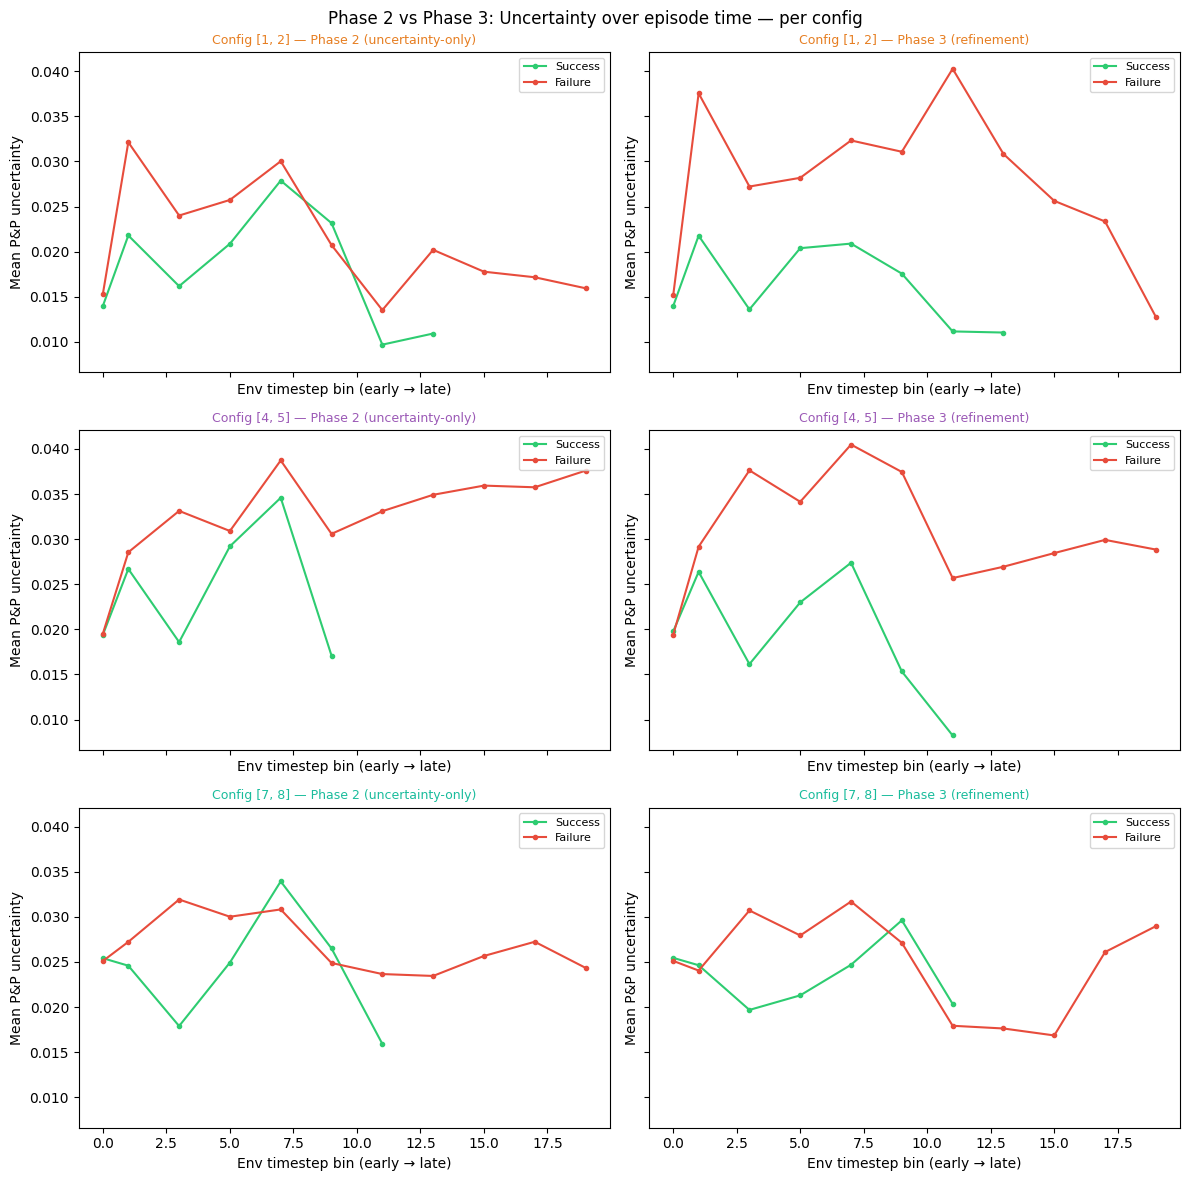

In [65]:
# ── Phase 2 vs Phase 3 over episode time — per config ─────────────────────────
by_chunk3_cfg = (
    steps_j3.groupby(['rollout_id', 'chunk_idx', 'success', 'pnp_step_indices'])
    .agg(u_mean_chunk=('u_mean', 'mean'))
    .reset_index()
)
by_chunk3_cfg['chunk_bin'] = pd.cut(by_chunk3_cfg['chunk_idx'], bins=N_BINS, labels=False)
by_bin3_cfg = (
    by_chunk3_cfg.groupby(['pnp_step_indices', 'chunk_bin', 'success'])
    .agg(u=('u_mean_chunk', 'mean'))
    .reset_index()
)

fig, axes = plt.subplots(len(configs), 2,
                          figsize=(12, 4 * len(configs)),
                          sharey=True, sharex=True)
if len(configs) == 1:
    axes = [axes]

for row_axes, cfg in zip(axes, configs):
    sub2 = by_bin2_cfg[by_bin2_cfg['pnp_step_indices'] == cfg]
    sub3 = by_bin3_cfg[by_bin3_cfg['pnp_step_indices'] == cfg]
    for ax, by_bin, phase_label in [
        (row_axes[0], sub2, 'Phase 2 (uncertainty-only)'),
        (row_axes[1], sub3, 'Phase 3 (refinement)'),
    ]:
        for outcome, label, color in [(1, 'Success', '#2ecc71'), (0, 'Failure', '#e74c3c')]:
            sub = by_bin[by_bin.success == outcome].sort_values('chunk_bin')
            if sub.empty:
                continue
            ax.plot(sub['chunk_bin'], sub['u'], marker='.', color=color, label=label)
        ax.set_xlabel('Env timestep bin (early → late)')
        ax.set_ylabel('Mean P&P uncertainty')
        ax.set_title(f'Config {cfg} — {phase_label}', fontsize=9,
                     color=config_colors.get(cfg, 'black'))
        ax.legend(fontsize=8)

fig.suptitle('Phase 2 vs Phase 3: Uncertainty over episode time — per config', fontsize=12)
plt.tight_layout()
plt.savefig('pnp_phase3_uncertainty_over_time.png', dpi=150)
plt.show()


Step-config comparison (aggregate):
config  n_p2    sr_p2  n_p3    sr_p3     u_p2     u_p3
[1, 2]    47 0.617021    47 0.680851 0.021317 0.021190
[4, 5]    47 0.595745    47 0.702128 0.027651 0.026464
[7, 8]    47 0.659574    47 0.595745 0.026789 0.026063


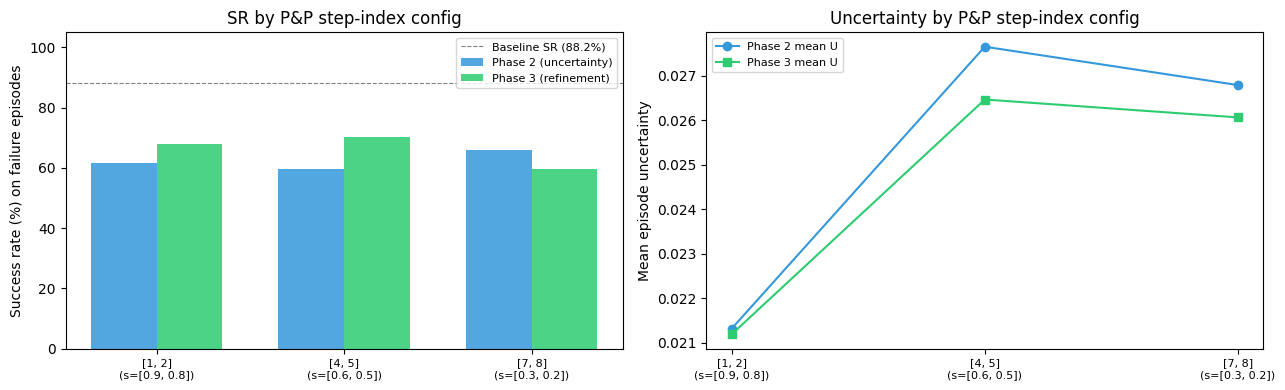


Per-step breakdown (which step within each config drives the signal):
config  euler_step   n   u_fail   u_succ  delta_u         r        p
[1, 2]           1 242 0.020939 0.017339 0.003600 -0.098346 0.127089
[1, 2]           2 242 0.025248 0.020807 0.004442 -0.116703 0.069944
[4, 5]           4 241 0.031986 0.023629 0.008357 -0.207214 0.001215
[4, 5]           5 241 0.030738 0.024142 0.006597 -0.166813 0.009476
[7, 8]           7 227 0.028308 0.024511 0.003797 -0.123897 0.062380
[7, 8]           8 227 0.027156 0.024801 0.002355 -0.099297 0.135832


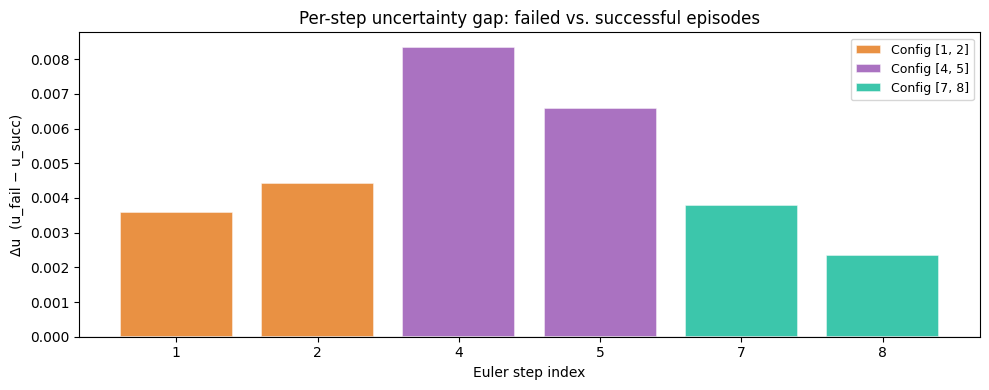

In [66]:
# ── Step-config comparison: SR and uncertainty across P&P step positions ──────
# Compares Phase 2 (uncertainty) and Phase 3 (refinement) success rates for each
# step-index config. Uses pnp_all (always unfiltered).

if len(all_step_configs) <= 1:
    print(f"Only one step config in DB ({all_step_configs}). Run additional STEP_CONFIGS "
          f"in test_pi05.ipynb to enable cross-config comparison.")
else:
    rows = []
    for cfg in all_step_configs:
        grp = pnp_all[pnp_all['pnp_step_indices'] == cfg]
        p2  = grp[grp['pnp_mode'] == 'uncertainty']
        p3  = grp[grp['pnp_mode'] == 'both']
        try:
            step_list = json.loads(cfg)
            num_steps = 10
            s_vals = [round(1.0 - i / num_steps, 1) for i in step_list]
            label = f"{cfg}\n(s={s_vals})"
        except Exception:
            label = cfg
        rows.append({
            'config': cfg, 'label': label,
            'n_p2': len(p2), 'sr_p2': p2.success.mean() if len(p2) else float('nan'),
            'n_p3': len(p3), 'sr_p3': p3.success.mean() if len(p3) else float('nan'),
            'u_p2': p2.u_mean_episode.mean() if len(p2) else float('nan'),
            'u_p3': p3.u_mean_episode.mean() if len(p3) else float('nan'),
        })

    cmp = pd.DataFrame(rows)
    print("Step-config comparison (aggregate):")
    print(cmp[['config','n_p2','sr_p2','n_p3','sr_p3','u_p2','u_p3']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    x = range(len(cmp))
    w = 0.35
    axes[0].bar([i - w/2 for i in x], cmp['sr_p2'] * 100, width=w,
                label='Phase 2 (uncertainty)', color='#3498db', alpha=0.85)
    axes[0].bar([i + w/2 for i in x], cmp['sr_p3'] * 100, width=w,
                label='Phase 3 (refinement)',  color='#2ecc71', alpha=0.85)
    axes[0].set_xticks(list(x)); axes[0].set_xticklabels(cmp['label'], fontsize=8)
    axes[0].set_ylabel('Success rate (%) on failure episodes')
    axes[0].set_ylim(0, 105)
    axes[0].axhline(baseline.success.mean() * 100, color='gray', linestyle='--',
                    linewidth=0.8, label=f'Baseline SR ({baseline.success.mean():.1%})')
    axes[0].legend(fontsize=8)
    axes[0].set_title('SR by P&P step-index config')

    axes[1].plot(list(x), cmp['u_p2'], marker='o', label='Phase 2 mean U', color='#3498db')
    axes[1].plot(list(x), cmp['u_p3'], marker='s', label='Phase 3 mean U', color='#2ecc71')
    axes[1].set_xticks(list(x)); axes[1].set_xticklabels(cmp['label'], fontsize=8)
    axes[1].set_ylabel('Mean episode uncertainty')
    axes[1].set_title('Uncertainty by P&P step-index config')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('pnp_step_config_comparison.png', dpi=150)
    plt.show()

    # ── Per-step breakdown within each config ─────────────────────────────────
    # Shows which of the two steps in each config drives the aggregate u_mean signal.
    steps_j2_cfg = steps_phase2.merge(
        phase2[['rollout_id', 'success', 'pnp_step_indices']], on='rollout_id', how='left')

    step_rows = []
    for cfg in all_step_configs:
        grp = steps_j2_cfg[steps_j2_cfg['pnp_step_indices'] == cfg]
        for step_idx, sgrp in grp.groupby('euler_step'):
            u_fail = sgrp.loc[sgrp['success'] == 0, 'u_mean'].mean()
            u_succ = sgrp.loc[sgrp['success'] == 1, 'u_mean'].mean()
            if sgrp['success'].nunique() == 2:
                r, p_val = pointbiserialr(sgrp['success'], sgrp['u_mean'])
            else:
                r, p_val = float('nan'), float('nan')
            step_rows.append({
                'config': cfg, 'euler_step': step_idx,
                'n': len(sgrp), 'u_fail': u_fail, 'u_succ': u_succ,
                'delta_u': u_fail - u_succ, 'r': r, 'p': p_val,
            })

    step_breakdown = pd.DataFrame(step_rows).sort_values(['config', 'euler_step'])
    print('\nPer-step breakdown (which step within each config drives the signal):')
    print(step_breakdown.to_string(index=False))

    # Plot: delta_u (fail - succ) per step, grouped by config
    fig, ax = plt.subplots(figsize=(10, 4))
    config_colors_local = {'[1, 2]': '#e67e22', '[4, 5]': '#9b59b6', '[7, 8]': '#1abc9c'}
    for cfg, grp in step_breakdown.groupby('config'):
        ax.bar(grp['euler_step'].astype(str), grp['delta_u'],
               color=config_colors_local.get(cfg, '#95a5a6'), alpha=0.85,
               label=f'Config {cfg}', edgecolor='white', linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Euler step index')
    ax.set_ylabel('Δu  (u_fail − u_succ)')
    ax.set_title('Per-step uncertainty gap: failed vs. successful episodes')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('pnp_per_step_uncertainty_gap.png', dpi=150)
    plt.show()
